Imports necessários, leitura das imagens de teste que serão usadas e funções básicas.

In [2]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
import cv2 as cv2
def normalizar_imagem(img):
    if (img.max()<=1):
        img *= 255
    img = img.astype(np.uint8)
    return img

#Linha a ser trocada para teste é abaixo
img_teste = normalizar_imagem(plt.imread('baboon_monocromatica.png'))

def escolha_imagem(original):
    opcao = int(input("1 - Imagem de teste original\n2 - Imagem de teste escolhida\n"))
    img = None
    if opcao == 1:
        img = original.copy()
    elif opcao == 2:
        img = img_teste.copy()
    else:
        print("Opção inválida, imagem original usada")
        img = original.copy()

    return img

def plotar_imagem(img,img_modificada, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    im1 = ax[0].imshow(img, cmap='gray')
    ax[0].set_title('Imagem Original')

    im2 = ax[1].imshow(img_modificada, cmap='gray')
    ax[1].set_title(titulo)

    plt.show()
    
def plotar_histograma(img, titulo):
    plt.figure(figsize=(8, 4))
    plt.hist(img.ravel(), bins=256, range=(0, 256), color='gray')
    plt.title('Histograma da Imagem - ' + titulo)
    plt.xlabel('Intensidade de Pixels')
    plt.ylabel('Frequência')
    plt.show()

def calcular_fracao_pretos(img):
    # Conta quantos pixels são iguais a 0
    pixels_pretos = np.sum(img == 0)
    
    # Calcula o total de pixels (largura x altura)
    total_pixels = img.size
    
    fracao = pixels_pretos / total_pixels
    
    print(f"Total de pixels: {total_pixels}")
    print(f"Pixels pretos: {pixels_pretos}")
    print(f"Fração de pretos: {fracao:.4f} ({fracao*100:.2f}%)")
    
    return fracao


Funções básicas que serão usadas no futuro. Para adicionar uma imagem nova basta inserir o nome do arquivo .png na variável img_teste seguindo os requisitos de cada célula para o tipo da imagem e então selecionar a opção 2 no primeiro input.

In [11]:
baboon_mono = normalizar_imagem(plt.imread('baboon_monocromatica.png'))
house = normalizar_imagem(plt.imread('house.png'))
butterfly = normalizar_imagem(plt.imread('butterfly.png'))

Abaixo está um bloco somente para geração dos histogramas

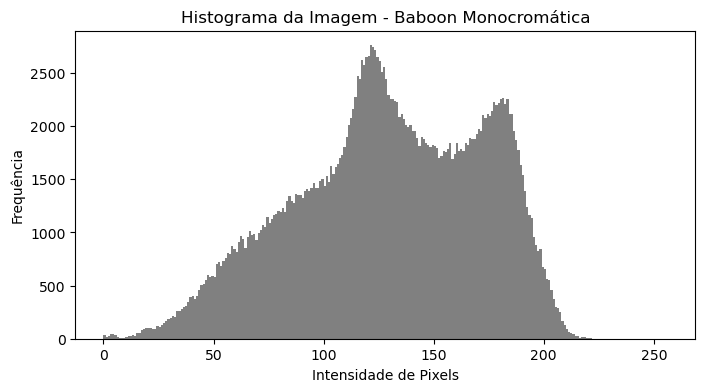

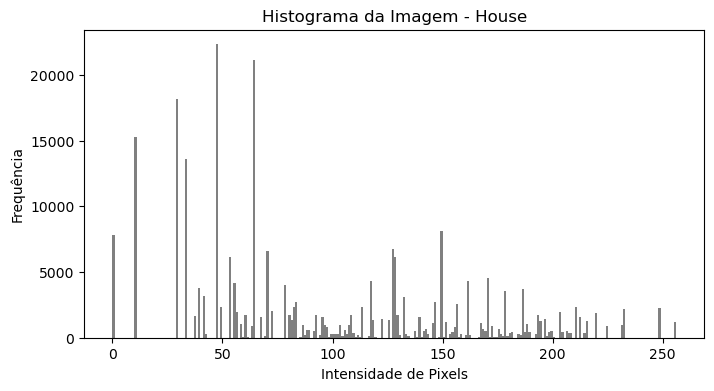

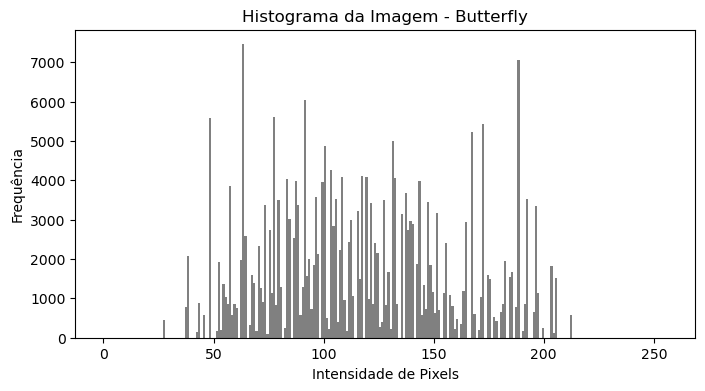

In [16]:
plotar_histograma(baboon_mono, "Baboon Monocromática")
plotar_histograma(house, "House")
plotar_histograma(butterfly, "Butterfly")

## **Métodos de Limiarização Globais**

**Método Global**

Total de pixels: 262144
Pixels pretos: 186501
Fração de pretos: 0.7114 (71.14%)


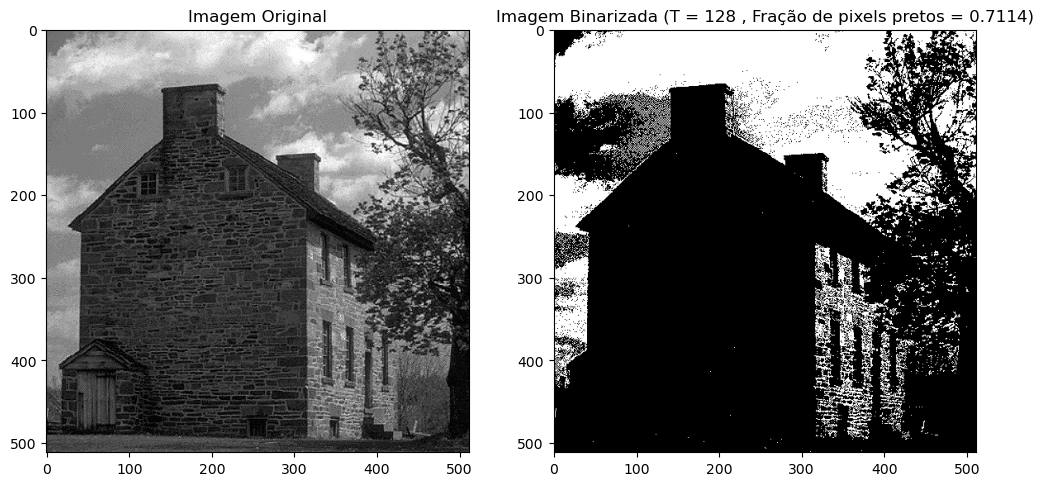

In [15]:
img = escolha_imagem(house)

T = int(input("Limiar de Binzarização (Valor de 0 a 255): "))

img = normalizar_imagem(img)

img_modificada = img.copy()

#Binarização das imagens
img_modificada = np.where(img_modificada > T, 255, 0)

plotar_imagem(img, img_modificada, f'Imagem Binarizada (T = {T} , Fração de pixels pretos = {calcular_fracao_pretos(img_modificada):.4f})')

**Método de Otsu**

Total de pixels: 262144
Pixels pretos: 125196
Fração de pretos: 0.4776 (47.76%)


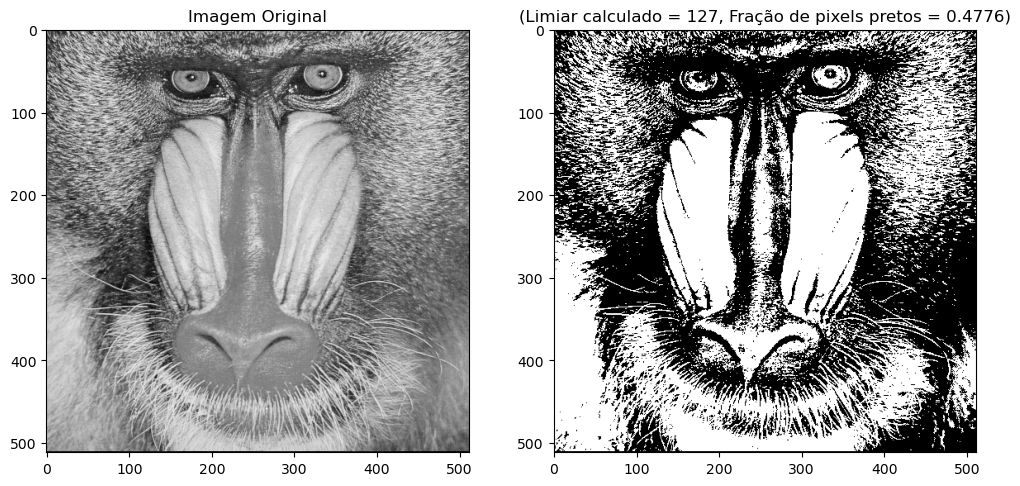

In [ ]:
img = escolha_imagem(baboon_mono)

img_modificada = img.copy()

#Método de Otsu
ret, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)

plotar_imagem(img, thresh, f'(Limiar calculado = {int(ret)}, Fração de pixels pretos = {calcular_fracao_pretos(thresh):.4f})')

## **Métodos de Limiarização Local**

**Método de Bernsen**

Total de pixels: 262144
Pixels pretos: 164976
Fração de pretos: 0.6293 (62.93%)


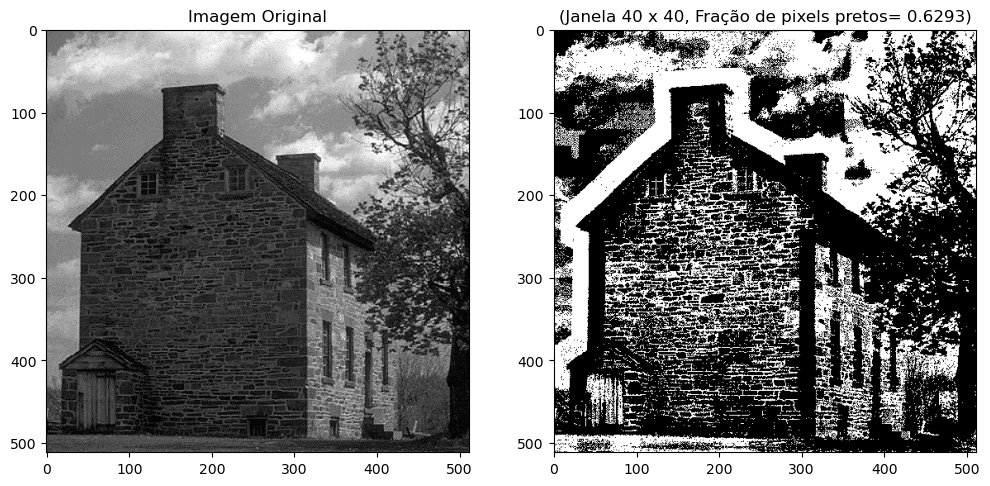

In [ ]:
def bernsen(img, n):
    # Padding necessário dado a forma que estamos pegando as janelas
    # posteriormente
    pad = n // 2
    if n % 2 == 0:
        pad_width = ((pad, pad-1), (pad, pad-1))
    else:
        pad_width = ((pad, pad), (pad, pad))
        
        
    img_padded = np.pad(img, pad_width, mode="edge")

    # Essencialmente cria uma matriz onde cada elemento é uma janela n x n
    # centrada em cada pixel da imagem original
    janelas = sliding_window_view(img_padded, (n, n))

    # Em cada pixel, encontra o valor máximo e mínimo dentro da janela n x n,
    # transformando o resultado para float32 para evitar problemas de overflow
    # no próximo passo
    z_max = janelas.max(axis=(-2, -1)).astype(np.float32)
    z_min = janelas.min(axis=(-2, -1)).astype(np.float32)

    T = (z_min + z_max) / 2.0

    resultado = np.where(img > T, 255, 0)

    return resultado.astype(np.uint8)

img = escolha_imagem(house)

img_modificada = img.copy()

n = int(input("Tamanho da janela para o método de Bernsen (n x n): "))
img_modificada = bernsen(img_modificada, n)

plotar_imagem(img, img_modificada, f"(Janela {n} x {n}, Fração de pixels pretos= {calcular_fracao_pretos(img_modificada):.4f})")

**Método de Niblack**

Total de pixels: 262144
Pixels pretos: 226789
Fração de pretos: 0.8651 (86.51%)


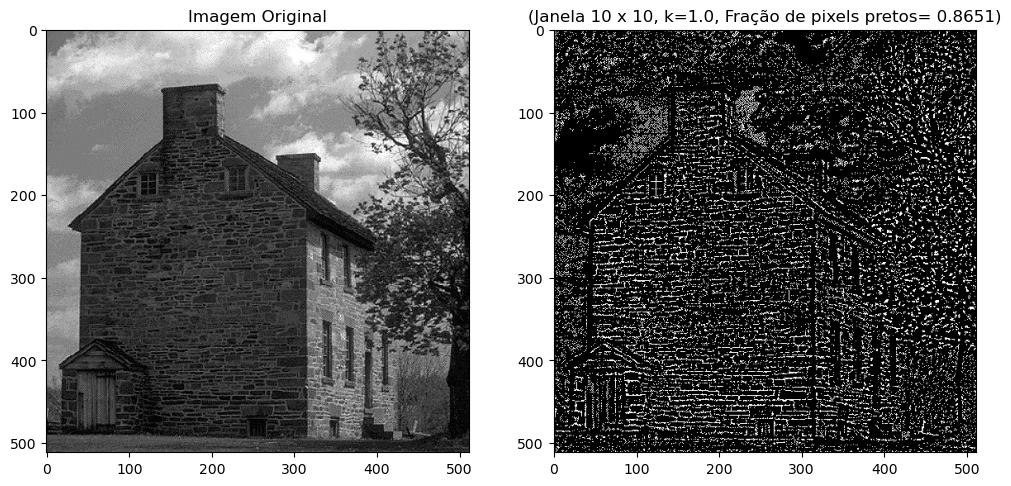

In [7]:
def niblack(img, n, k):
    # Padding necessário dado a forma que estamos pegando as janelas
    # posteriormente
    pad = n // 2
    if n % 2 == 0:
        pad_width = ((pad, pad-1), (pad, pad-1))
    else:
        pad_width = ((pad, pad), (pad, pad))
        
        
    img_padded = np.pad(img, pad_width, mode="edge").astype(np.float32)

    # Essencialmente cria uma matriz onde cada elemento é uma janela n x n
    # centrada em cada pixel da imagem original
    janelas = sliding_window_view(img_padded, (n, n))

    # Em cada pixel, encontra o valor da média que posteriormente será usada para
    # calcular o desvio padrão local, transformando o resultado para float32 para
    # evitar problemas de overflow
    media = janelas.mean(axis=(-2, -1)).astype(np.float32)
    
    # Média dos quadrados local
    janelas_quadrado = sliding_window_view(img_padded**2, (n, n))
    media_quadrado = janelas_quadrado.mean(axis=(-2, -1))
    
    # Desvio padrão = sqrt(média_dos_quadrados - média^2)
    variancia = np.clip(media_quadrado - media**2, 0, None)
    desvio_padrao = np.sqrt(variancia)
    
    T = media + k * desvio_padrao

    resultado = np.where(img > T, 255, 0)

    return resultado.astype(np.uint8)

img = escolha_imagem(house)

img_modificada = img.copy()

n = int(input("Tamanho da janela para o método de Niblack (n x n): "))
k = float(input("Valor de k para o método de Niblack: "))
img_modificada = niblack(img_modificada, n, k)

plotar_imagem(img, img_modificada, f"(Janela {n} x {n}, k={k}, Fração de pixels pretos= {calcular_fracao_pretos(img_modificada):.4f})")

**Método de Sauvola e Pietaksinen**

Total de pixels: 262144
Pixels pretos: 90481
Fração de pretos: 0.3452 (34.52%)


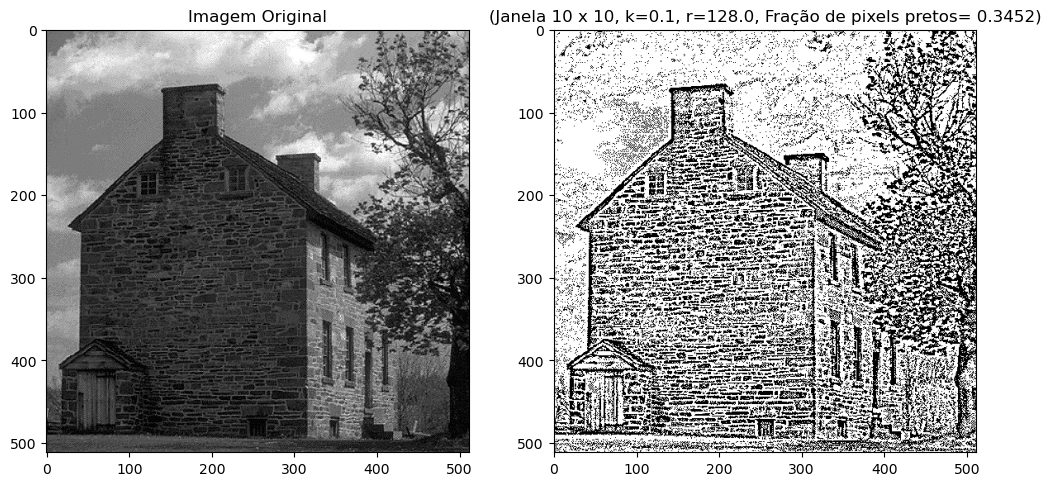

In [11]:
def sauvolaPietaksinen(img, n, k, r):
    # Padding necessário dado a forma que estamos pegando as janelas
    # posteriormente
    pad = n // 2
    if n % 2 == 0:
        pad_width = ((pad, pad-1), (pad, pad-1))
    else:
        pad_width = ((pad, pad), (pad, pad))
        
        
    img_padded = np.pad(img, pad_width, mode="edge").astype(np.float32)

    # Essencialmente cria uma matriz onde cada elemento é uma janela n x n
    # centrada em cada pixel da imagem original
    janelas = sliding_window_view(img_padded, (n, n))

    # Em cada pixel, encontra o valor da média que posteriormente será usada para
    # calcular o desvio padrão local, transformando o resultado para float32 para
    # evitar problemas de overflow
    media = janelas.mean(axis=(-2, -1)).astype(np.float32)
    
    # Média dos quadrados local
    janelas_quadrado = sliding_window_view(img_padded**2, (n, n))
    media_quadrado = janelas_quadrado.mean(axis=(-2, -1))
    
    # Desvio padrão = sqrt(média_dos_quadrados - média^2)
    variancia = np.clip(media_quadrado - media**2, 0, None)
    desvio_padrao = np.sqrt(variancia)
    
    T = media *(1 + k * ((desvio_padrao/r) - 1))

    resultado = np.where(img > T, 255, 0)

    return resultado.astype(np.uint8)

img = escolha_imagem(house)

img_modificada = img.copy()

n = int(input("Tamanho da janela para o método de Sauvola-Pietaksinen (n x n): "))
k = float(input("Valor de k para o método de Sauvola-Pietaksinen: "))
r = float(input("Valor de r para o método de Sauvola-Pietaksinen: "))
img_modificada = sauvolaPietaksinen(img_modificada, n, k, r)

plotar_imagem(img, img_modificada, f"(Janela {n} x {n}, k={k}, r={r}, Fração de pixels pretos= {calcular_fracao_pretos(img_modificada):.4f})")

**Método de Phansalskar, More e Sabale**

Total de pixels: 262144
Pixels pretos: 50803
Fração de pretos: 0.1938 (19.38%)


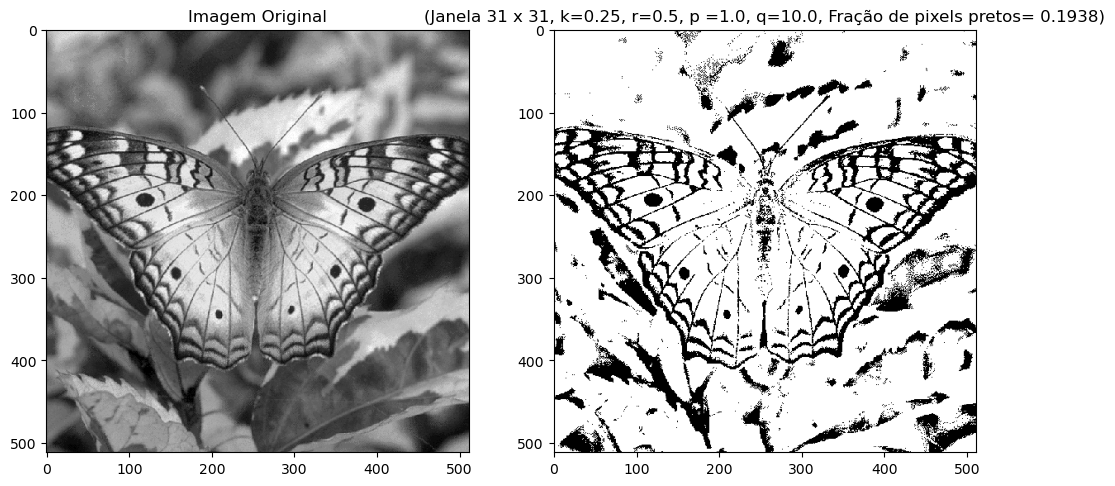

In [22]:
def phansalkarMoreSabale(img, n, k, r, p, q):
    # Padding necessário dado a forma que estamos pegando as janelas
    # posteriormente
    pad = n // 2
    if n % 2 == 0:
        pad_width = ((pad, pad-1), (pad, pad-1))
    else:
        pad_width = ((pad, pad), (pad, pad))
        
    img_normalizada = img.astype(np.float32) / 255.0
    img_padded = np.pad(img_normalizada, pad_width, mode="edge").astype(np.float32)

    # Essencialmente cria uma matriz onde cada elemento é uma janela n x n
    # centrada em cada pixel da imagem original
    janelas = sliding_window_view(img_padded, (n, n))

    # Em cada pixel, encontra o valor da média que posteriormente será usada para
    # calcular o desvio padrão local, transformando o resultado para float32 para
    # evitar problemas de overflow
    media = janelas.mean(axis=(-2, -1)).astype(np.float32)
    
    # Média dos quadrados local
    janelas_quadrado = sliding_window_view(img_padded**2, (n, n))
    media_quadrado = janelas_quadrado.mean(axis=(-2, -1))
    
    # Desvio padrão = sqrt(média_dos_quadrados - média^2)
    variancia = np.clip(media_quadrado - media**2, 0, None)
    desvio_padrao = np.sqrt(variancia)
    
    termo_exponencial = p * np.exp(-q * media)
    termo_contraste = k * ((desvio_padrao / r) - 1)
    
    T = media * (1 + termo_exponencial + termo_contraste)

    resultado = np.where(img_normalizada > T, 255, 0)

    return resultado.astype(np.uint8)

img = escolha_imagem(butterfly)

img_modificada = img.copy()

n = int(input("Tamanho da janela para o método de Phansalskar, More e Sabale (n x n): "))
k = float(input("Valor de k para o método de Phansalskar, More e Sabale: "))
r = float(input("Valor de r para o método de Phansalskar, More e Sabale: "))
p = float(input("Valor de p para o método de Phansalskar, More e Sabale: "))
q = float(input("Valor de q para o método de Phansalskar, More e Sabale: "))
img_modificada = phansalkarMoreSabale(img_modificada, n, k, r, p, q)

plotar_imagem(img, img_modificada, f"(Janela {n} x {n}, k={k}, r={r}, p ={p}, q={q}, Fração de pixels pretos= {calcular_fracao_pretos(img_modificada):.4f})")

**Método de Constraste**

Total de pixels: 262144
Pixels pretos: 136542
Fração de pretos: 0.5209 (52.09%)


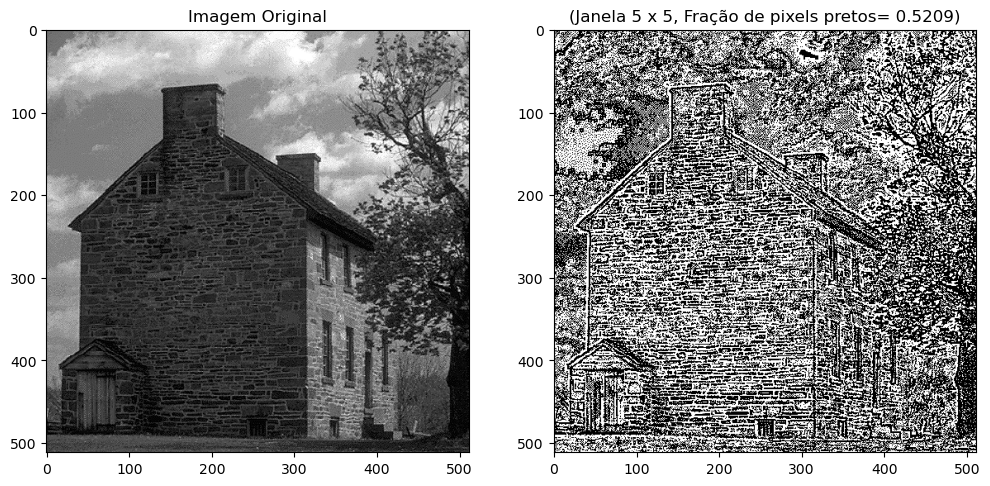

In [27]:
def contraste(img, n):
    # Padding necessário dado a forma que estamos pegando as janelas
    # posteriormente
    pad = n // 2
    if n % 2 == 0:
        pad_width = ((pad, pad-1), (pad, pad-1))
    else:
        pad_width = ((pad, pad), (pad, pad))
        
    img_padded = np.pad(img, pad_width, mode="edge").astype(np.float32)

    # Essencialmente cria uma matriz onde cada elemento é uma janela n x n
    # centrada em cada pixel da imagem original
    janelas = sliding_window_view(img_padded, (n, n))

    max = janelas.max(axis=(-2, -1)).astype(np.float32)
    min = janelas.min(axis=(-2, -1)).astype(np.float32)
    
    distancia_ao_max = np.abs(img - max)
    distancia_ao_min = np.abs(img - min)
    
    resultado = np.where(distancia_ao_max >= distancia_ao_min, 0, 255)

    return resultado.astype(np.uint8)

img = escolha_imagem(house)

img_modificada = img.copy()

n = int(input("Tamanho da janela para o método de Contraste (n x n): "))
img_modificada = contraste(img_modificada, n)

plotar_imagem(img, img_modificada, f"(Janela {n} x {n}, Fração de pixels pretos= {calcular_fracao_pretos(img_modificada):.4f})")

**Método da Média**

Total de pixels: 262144
Pixels pretos: 86172
Fração de pretos: 0.3287 (32.87%)


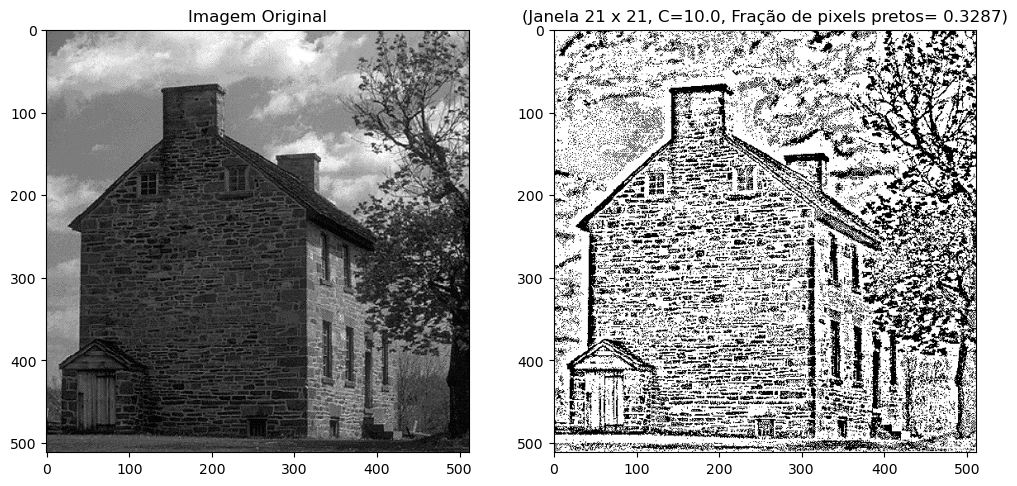

In [13]:
def mediaComConstante(img, n, C):
    # Padding necessário dado a forma que estamos pegando as janelas
    # posteriormente
    pad = n // 2
    if n % 2 == 0:
        pad_width = ((pad, pad-1), (pad, pad-1))
    else:
        pad_width = ((pad, pad), (pad, pad))
        
        
    img_padded = np.pad(img, pad_width, mode="edge").astype(np.float32)

    # Essencialmente cria uma matriz onde cada elemento é uma janela n x n
    # centrada em cada pixel da imagem original
    janelas = sliding_window_view(img_padded, (n, n))

    # Em cada pixel, encontra o valor da média
    media = janelas.mean(axis=(-2, -1)).astype(np.float32)
    
    T = np.maximum(media - C, 0)
    
    resultado = np.where(img > T, 255, 0)

    return resultado.astype(np.uint8)

img = escolha_imagem(house)

img_modificada = img.copy()

n = int(input("Tamanho da janela para o método da Média (n x n): "))
C = float(input("Valor de C para o método da Média: "))
img_modificada = mediaComConstante(img_modificada, n, C)

plotar_imagem(img, img_modificada, f"(Janela {n} x {n}, C={C}, Fração de pixels pretos= {calcular_fracao_pretos(img_modificada):.4f})")

**Método da Mediana**

Total de pixels: 262144
Pixels pretos: 148031
Fração de pretos: 0.5647 (56.47%)


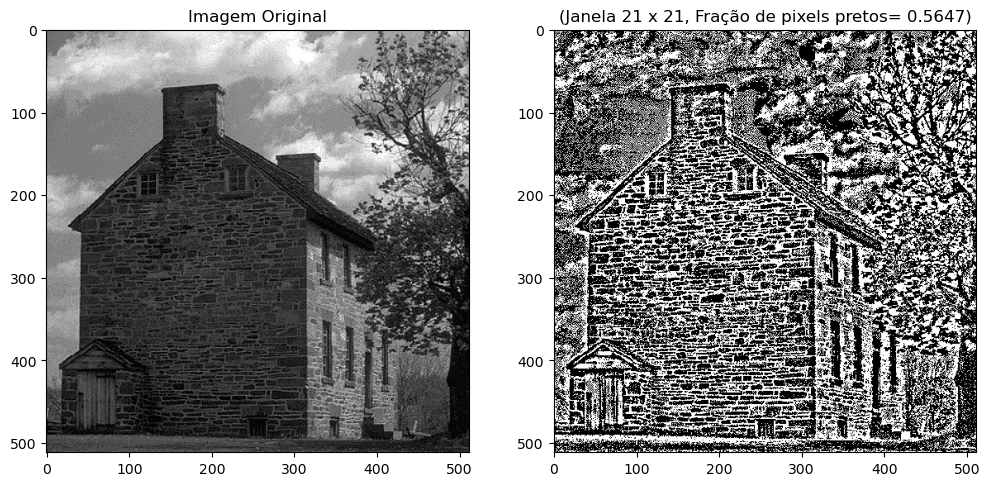

In [14]:
def metodoMediana(img, n):
    # Padding necessário dado a forma que estamos pegando as janelas
    # posteriormente
    pad = n // 2
    if n % 2 == 0:
        pad_width = ((pad, pad-1), (pad, pad-1))
    else:
        pad_width = ((pad, pad), (pad, pad))
        
        
    img_padded = np.pad(img, pad_width, mode="edge").astype(np.float32)

    # Essencialmente cria uma matriz onde cada elemento é uma janela n x n
    # centrada em cada pixel da imagem original
    janelas = sliding_window_view(img_padded, (n, n))

    # Em cada pixel, encontra o valor da mediana
    mediana = np.median(janelas, axis=(-2, -1)).astype(np.float32)

    T = mediana
    
    resultado = np.where(img > T, 255, 0)
    
    return resultado.astype(np.uint8)

img = escolha_imagem(house)

img_modificada = img.copy()

n = int(input("Tamanho da janela para o método da Média (n x n): "))
img_modificada = metodoMediana(img_modificada, n)

plotar_imagem(img, img_modificada, f"(Janela {n} x {n}, Fração de pixels pretos= {calcular_fracao_pretos(img_modificada):.4f})")